In [137]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [138]:
base = Path(".")

seq = pd.read_csv(base / "sequential.csv")
rnd = pd.read_csv(base / "random.csv")
rnd_pre = pd.read_csv(base / "random_precomputed.csv")

seq["mode"] = "sequential"
rnd["mode"] = "random"
rnd_pre["mode"] = "random_precomputed"

df = pd.concat([seq, rnd, rnd_pre], ignore_index=True)

for name, part in [("sequential", seq), ("random", rnd), ("random_precomputed", rnd_pre)]:
    print(name, part.shape)
    display(part.head())

sequential (2132, 6)


,size_bytes,size_kb,size_mb,elements,cycles_per_iteration,mode
0,1024,1,0.000977,256,7.89453,sequential
1,2048,2,0.001953,512,1.76367,sequential
2,3072,3,0.002930,768,1.45573,sequential
3,4096,4,0.003906,1024,1.63770,sequential
4,5120,5,0.004883,1280,1.67969,sequential


random (2132, 6)


,size_bytes,size_kb,size_mb,elements,cycles_per_iteration,mode
0,1024,1,0.000977,256,26.2031,random
1,2048,2,0.001953,512,20.2402,random
2,3072,3,0.002930,768,37.0091,random
3,4096,4,0.003906,1024,16.7969,random
4,5120,5,0.004883,1280,17.9055,random


random_precomputed (2132, 6)


,size_bytes,size_kb,size_mb,elements,cycles_per_iteration,mode
0,1024,1,0.000977,256,16.46090,random_precomputed
1,2048,2,0.001953,512,2.93945,random_precomputed
2,3072,3,0.002930,768,1.84766,random_precomputed
3,4096,4,0.003906,1024,1.76367,random_precomputed
4,5120,5,0.004883,1280,1.74687,random_precomputed


In [139]:
def prepare_df(df: pd.DataFrame, mode: str, use_index_array: bool = False) -> pd.DataFrame:
    x = df.copy().sort_values("size_bytes").reset_index(drop=True)
    x["mode"] = mode

    if use_index_array:
        x["effective_bytes"] = x["elements"] * 4 + x["elements"] * 4
    else:
        x["effective_bytes"] = x["size_bytes"]

    x["size_kb_plot"] = x["effective_bytes"] / 1024.0
    x["size_mb_plot"] = x["effective_bytes"] / (1024.0 * 1024.0)

    x["smooth"] = x["cycles_per_iteration"].rolling(
        window=5, center=True, min_periods=1
    ).median()

    return x


seq_p = prepare_df(seq, "sequential", use_index_array=False)
rnd_p = prepare_df(rnd, "random", use_index_array=False)
rnd_pre_p = prepare_df(rnd_pre, "random_precomputed", use_index_array=True)

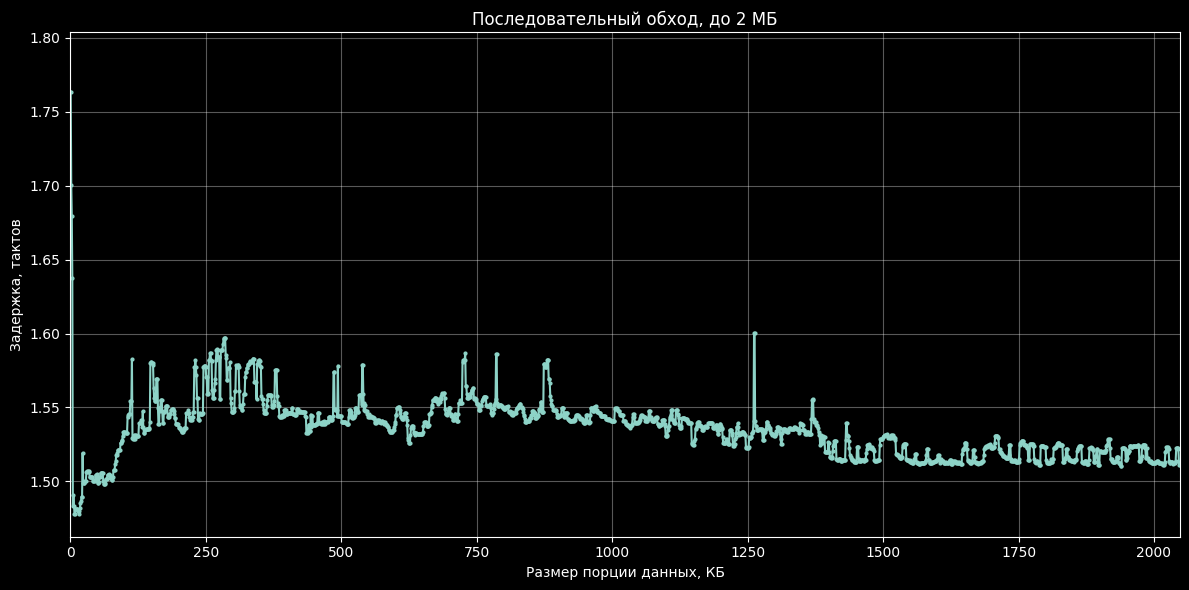

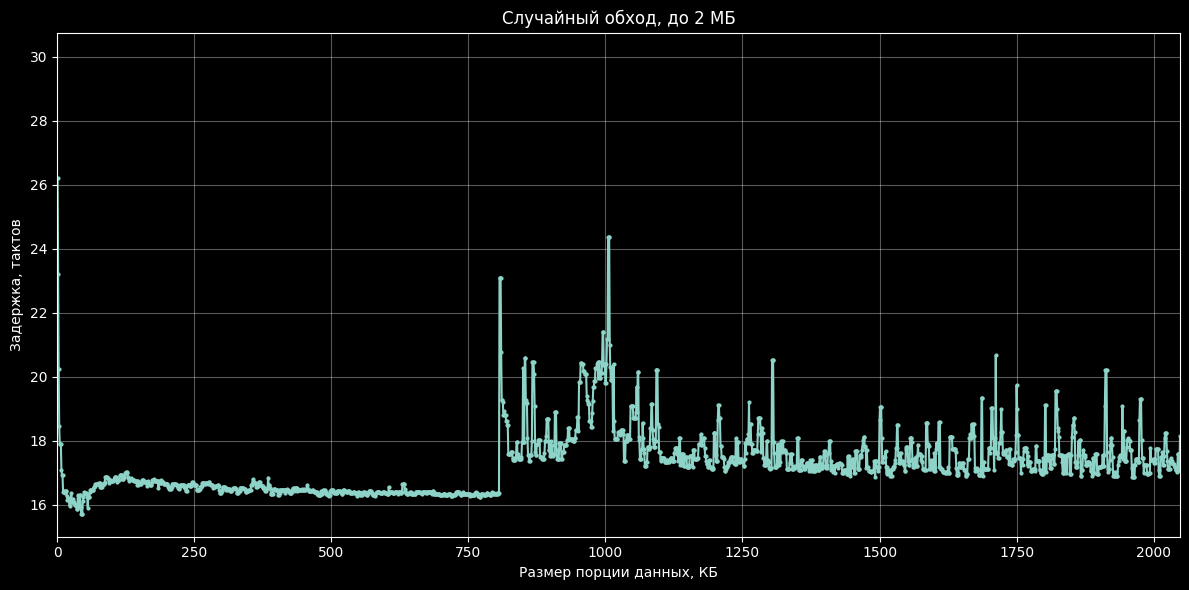

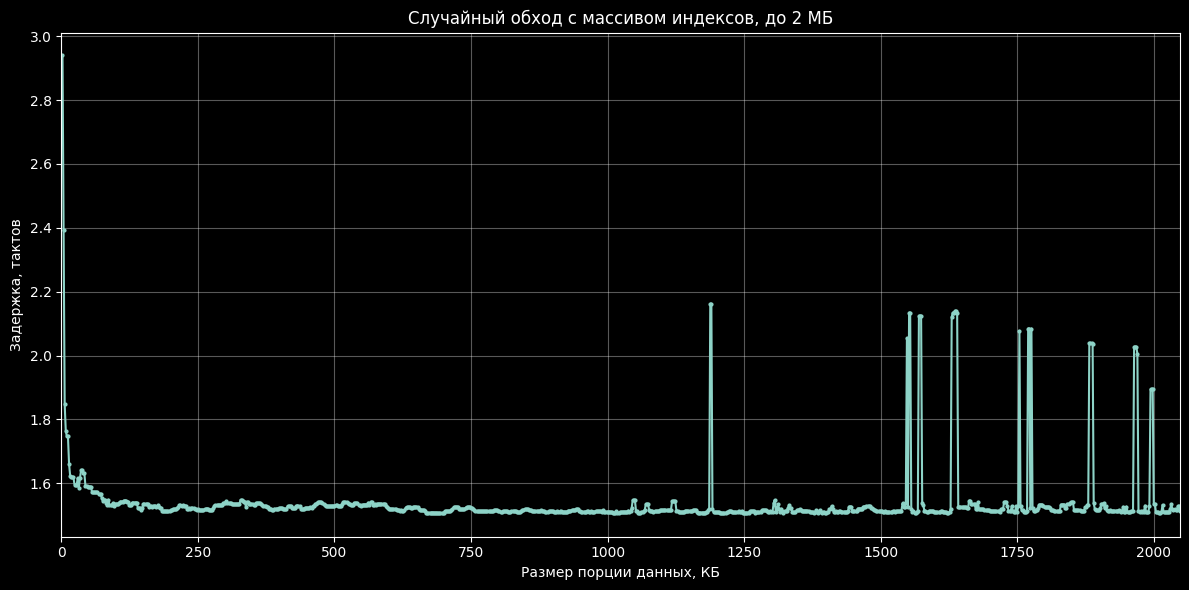

In [140]:
def plot_simple(df: pd.DataFrame, title: str, x_max_kb=None, y_min=None, y_max=None):
    plt.figure(figsize=(12, 6))
    plt.plot(df["size_kb_plot"], df["smooth"], marker="o", markersize=2, linewidth=1.5)

    plt.xlabel("Размер порции данных, КБ")
    plt.ylabel("Задержка, тактов")
    plt.title(title)
    plt.grid(True, alpha=0.35)

    if x_max_kb is not None:
        plt.xlim(0, x_max_kb)
    if y_min is not None or y_max is not None:
        plt.ylim(y_min, y_max)

    plt.tight_layout()
    plt.show()


plot_simple(seq_p, "Последовательный обход, до 2 МБ", x_max_kb=2048)
plot_simple(rnd_p, "Случайный обход, до 2 МБ", x_max_kb=2048)
plot_simple(rnd_pre_p, "Случайный обход с массивом индексов, до 2 МБ", x_max_kb=2048)

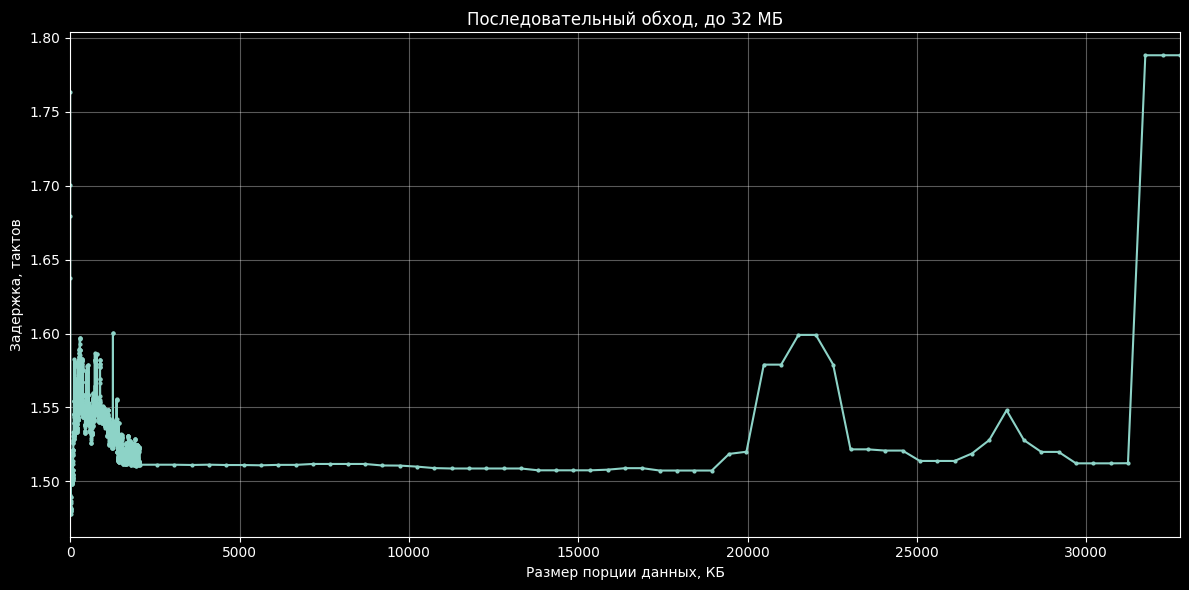

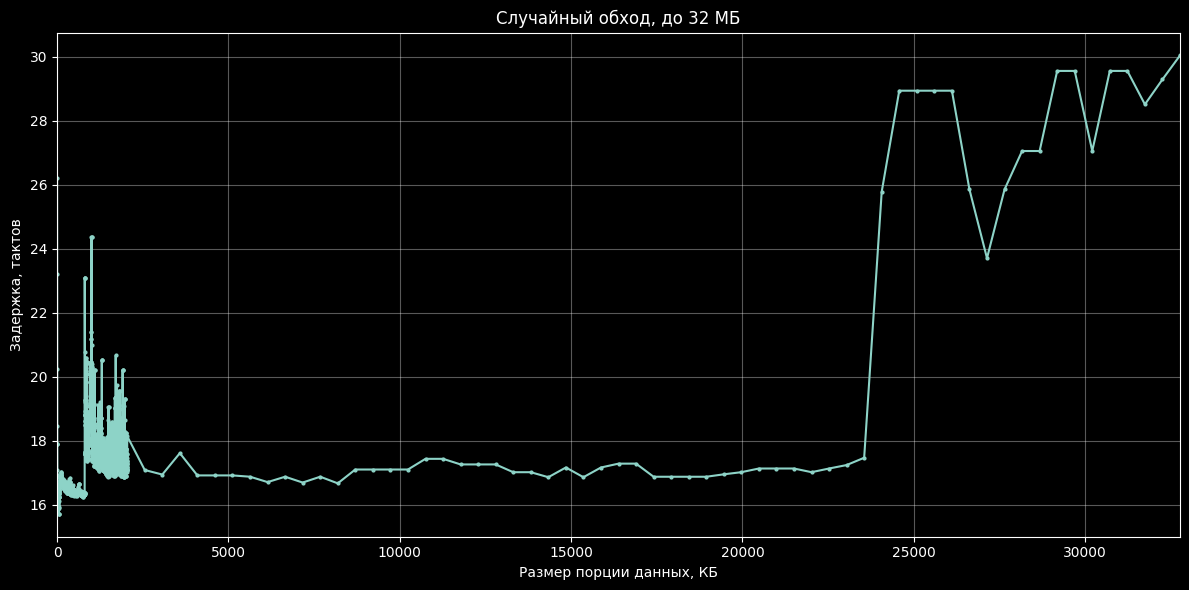

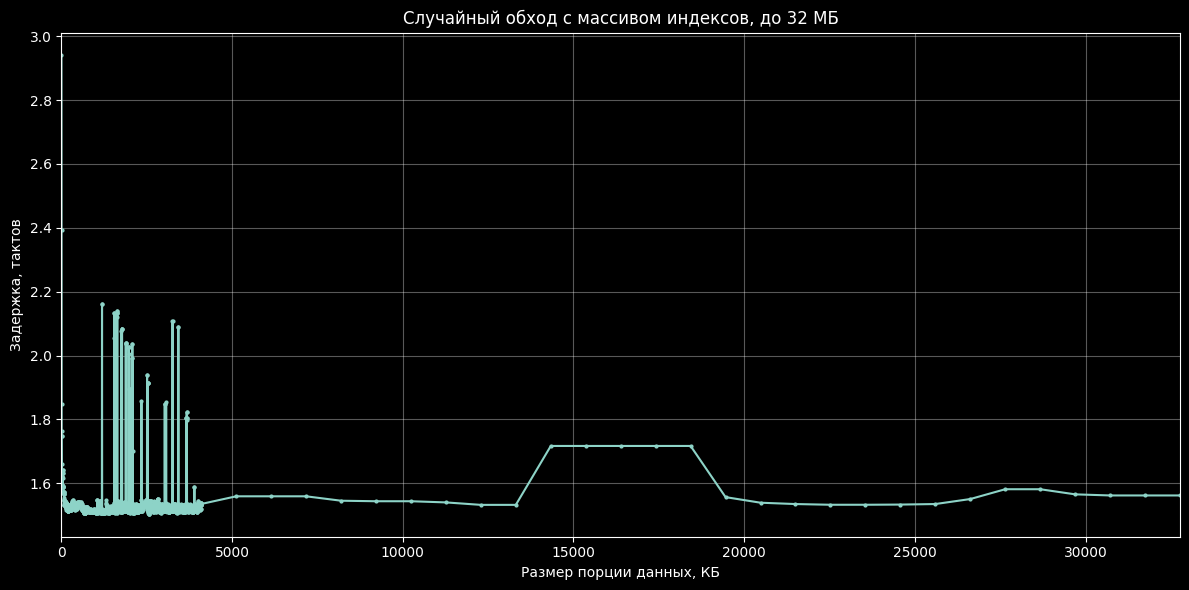

In [141]:
plot_simple(seq_p, "Последовательный обход, до 32 МБ", x_max_kb=32768)
plot_simple(rnd_p, "Случайный обход, до 32 МБ", x_max_kb=32768)
plot_simple(rnd_pre_p, "Случайный обход с массивом индексов, до 32 МБ", x_max_kb=32768)

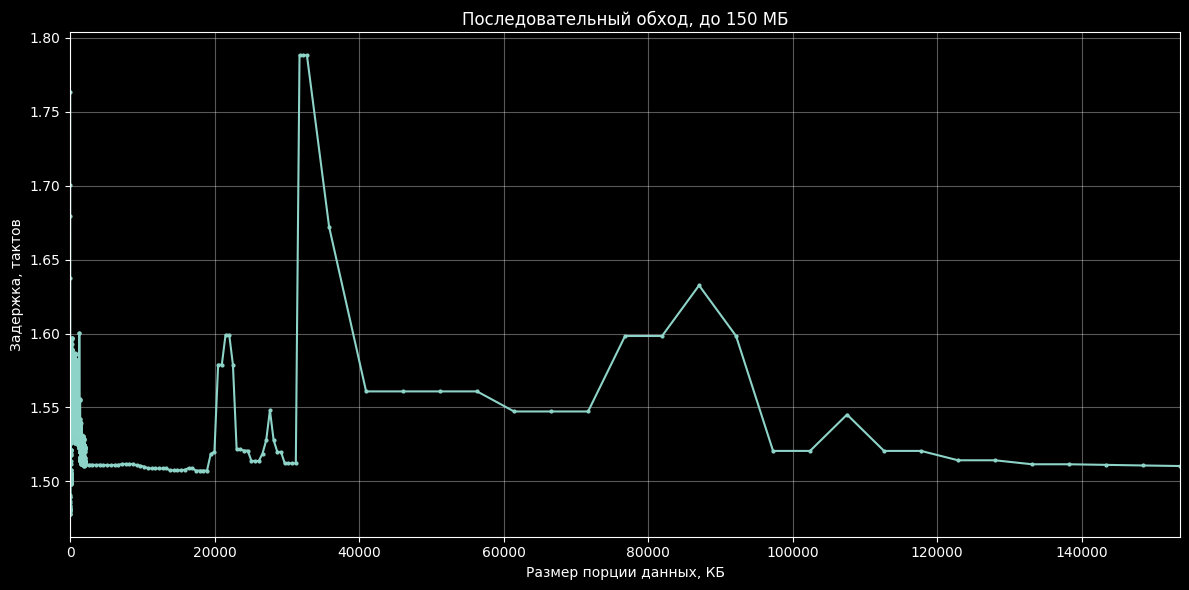

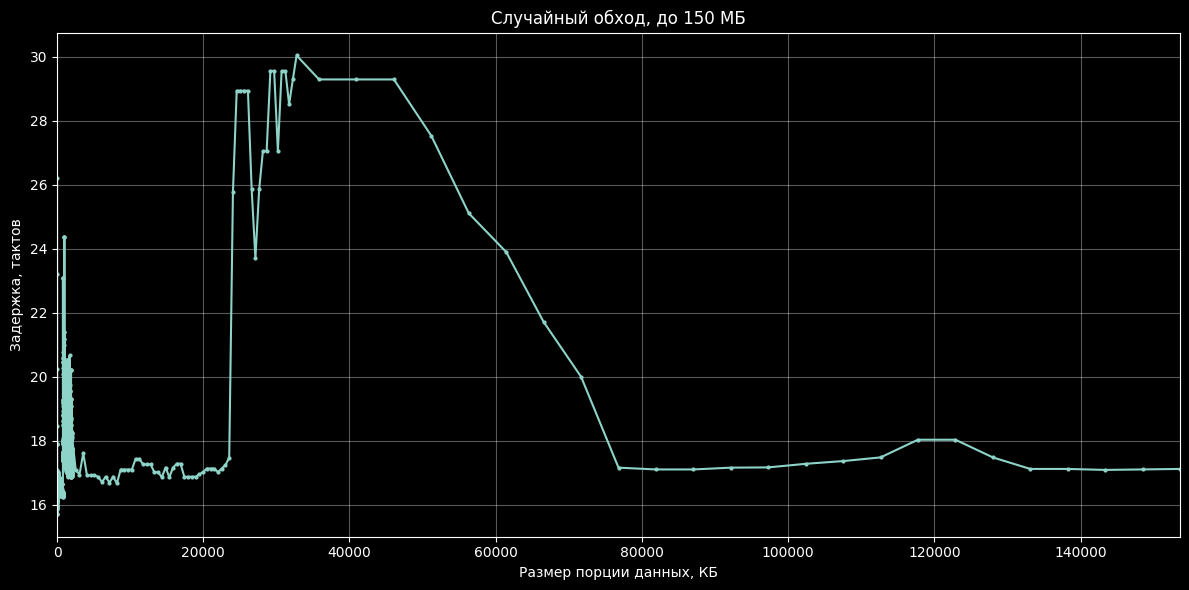

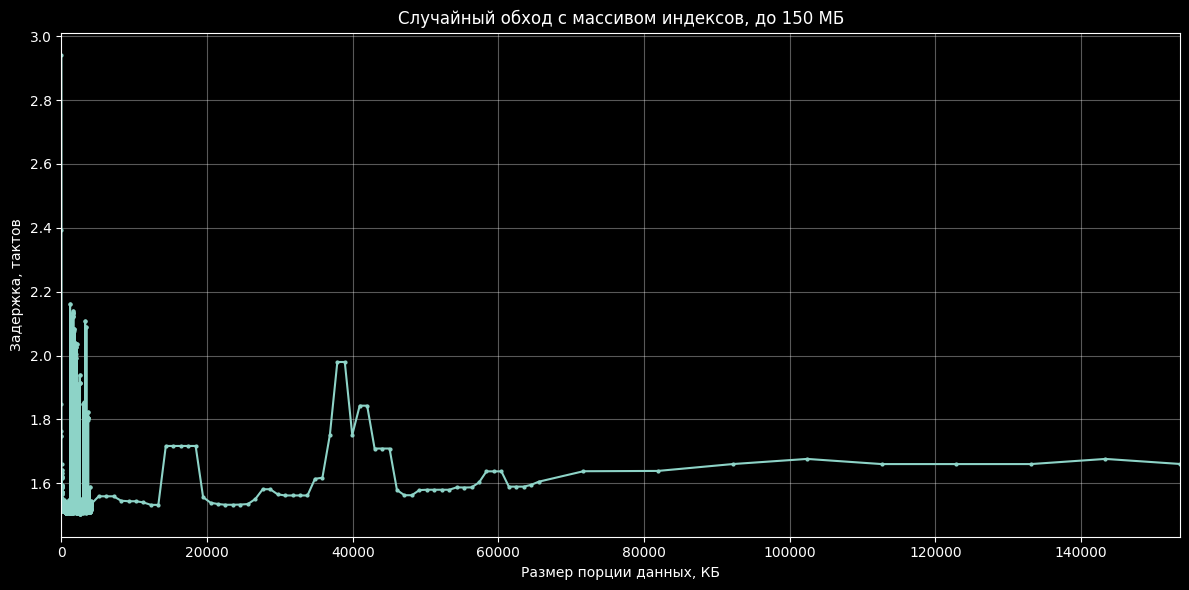

In [142]:
plot_simple(seq_p, "Последовательный обход, до 150 МБ", x_max_kb=153600)
plot_simple(rnd_p, "Случайный обход, до 150 МБ", x_max_kb=153600)
plot_simple(rnd_pre_p, "Случайный обход с массивом индексов, до 150 МБ", x_max_kb=153600)

In [143]:
REGIONS = {
    "sequential": {
        "effective": (1, 153600),
    },
    "random": {
        "L1":  (1, 64),
        "L2":  (64, 1024),
        "L3":  (1024, 32768),
        "RAM": (32768, 153600),
    },
    "random_precomputed": {
        "L1":  (1, 32),
        "L2":  (32, 512),
        "L3":  (512, 16384),
        "RAM": (16384, 153600),
    }
}

In [144]:
def estimate_latency(df: pd.DataFrame, left_kb: float, right_kb: float) -> float:
    part = df[(df["size_kb_plot"] >= left_kb) & (df["size_kb_plot"] <= right_kb)]
    if part.empty:
        return np.nan
    return float(part["smooth"].median())


def build_latency_table(seq_df, rnd_df, rnd_pre_df, regions):
    rows = []

    rows.append({
        "mode": "sequential",
        "effective": estimate_latency(seq_df, *regions["sequential"]["effective"]),
        "L1": np.nan,
        "L2": np.nan,
        "L3": np.nan,
        "RAM": np.nan,
    })

    rows.append({
        "mode": "random",
        "effective": np.nan,
        "L1": estimate_latency(rnd_df, *regions["random"]["L1"]),
        "L2": estimate_latency(rnd_df, *regions["random"]["L2"]),
        "L3": estimate_latency(rnd_df, *regions["random"]["L3"]),
        "RAM": estimate_latency(rnd_df, *regions["random"]["RAM"]),
    })

    rows.append({
        "mode": "random_precomputed",
        "effective": np.nan,
        "L1": estimate_latency(rnd_pre_df, *regions["random_precomputed"]["L1"]),
        "L2": estimate_latency(rnd_pre_df, *regions["random_precomputed"]["L2"]),
        "L3": estimate_latency(rnd_pre_df, *regions["random_precomputed"]["L3"]),
        "RAM": estimate_latency(rnd_pre_df, *regions["random_precomputed"]["RAM"]),
    })

    return pd.DataFrame(rows)


latency_table = build_latency_table(seq_p, rnd_p, rnd_pre_p, REGIONS)
latency_table

,mode,effective,L1,L2,L3,RAM
0,sequential,1.536185,NaN,NaN,NaN,NaN
1,random,NaN,16.277250,16.52750,17.40990,17.482400
2,random_precomputed,NaN,1.621155,1.52998,1.51766,1.592225


In [145]:
latency_table.to_csv("latency_table_estimated.csv", index=False)
print(latency_table)
print("Сохранено: latency_table_estimated.csv")

                 mode  effective         L1        L2        L3        RAM
0          sequential   1.536185        NaN       NaN       NaN        NaN
1              random        NaN  16.277250  16.52750  17.40990  17.482400
2  random_precomputed        NaN   1.621155   1.52998   1.51766   1.592225
Сохранено: latency_table_estimated.csv


In [146]:
REFERENCE = {
    "Intel Atom N270": {
        "sequential": {"effective": "29"},
        "random": {"L1": "25-30", "L2": "45-55", "L3": "-", "RAM": "240-340"},
        "random_precomputed": {"L1": "6", "L2": "26", "L3": "-", "RAM": "до 210"},
    },
    "Intel Core i7 4770": {
        "sequential": {"effective": "8-9"},
        "random": {"L1": "9", "L2": "9", "L3": "14-16", "RAM": "до 106"},
        "random_precomputed": {"L1": "1", "L2": "2-3", "L3": "10-24", "RAM": "до 100"},
    },
    "AMD Ryzen 7 7700": {
        "sequential": {"effective": "7-8"},
        "random": {"L1": "7", "L2": "7", "L3": "7-8 (до 16 МБ), 8-18 (до 32 МБ)", "RAM": "23"},
        "random_precomputed": {"L1": "1", "L2": "1-2", "L3": "2-3 (до 16 МБ), 3-10 (до 32 МБ)", "RAM": "до 16"},
    }
}

REFERENCE_CPU = "AMD Ryzen 7 7700"

ref_rows = [
    {
        "mode": "sequential",
        "effective_ref": REFERENCE[REFERENCE_CPU]["sequential"]["effective"],
        "L1_ref": "",
        "L2_ref": "",
        "L3_ref": "",
        "RAM_ref": "",
    },
    {
        "mode": "random",
        "effective_ref": "",
        "L1_ref": REFERENCE[REFERENCE_CPU]["random"]["L1"],
        "L2_ref": REFERENCE[REFERENCE_CPU]["random"]["L2"],
        "L3_ref": REFERENCE[REFERENCE_CPU]["random"]["L3"],
        "RAM_ref": REFERENCE[REFERENCE_CPU]["random"]["RAM"],
    },
    {
        "mode": "random_precomputed",
        "effective_ref": "",
        "L1_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["L1"],
        "L2_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["L2"],
        "L3_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["L3"],
        "RAM_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["RAM"],
    }
]

ref_df = pd.DataFrame(ref_rows)
comparison = latency_table.merge(ref_df, on="mode", how="left")
comparison

,mode,effective,L1,L2,L3,RAM,effective_ref,L1_ref,L2_ref,L3_ref,RAM_ref
0,sequential,1.536185,NaN,NaN,NaN,NaN,7-8,,,,
1,random,NaN,16.277250,16.52750,17.40990,17.482400,,7,7,"7-8 (до 16 МБ), 8-18 (до 32 МБ)",23
2,random_precomputed,NaN,1.621155,1.52998,1.51766,1.592225,,1,1-2,"2-3 (до 16 МБ), 3-10 (до 32 МБ)",до 16


In [147]:
comparison.to_csv("latency_table_comparison.csv", index=False)
print(comparison)
print("Сохранено: latency_table_comparison.csv")

                 mode  effective         L1        L2        L3        RAM  \
0          sequential   1.536185        NaN       NaN       NaN        NaN   
1              random        NaN  16.277250  16.52750  17.40990  17.482400   
2  random_precomputed        NaN   1.621155   1.52998   1.51766   1.592225   

  effective_ref L1_ref L2_ref                           L3_ref RAM_ref  
0           7-8                                                         
1                    7      7  7-8 (до 16 МБ), 8-18 (до 32 МБ)      23  
2                    1    1-2  2-3 (до 16 МБ), 3-10 (до 32 МБ)   до 16  
Сохранено: latency_table_comparison.csv
